In [1]:
import sys
sys.path.append("../")

import os
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"

%load_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

import numpy as np
import arviz as az
import mpltern
import corner

/n/home07/yitians/anaconda3/envs/torch/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
#mpl.rc_file('../notebooks/matplotlibrc')
import mpltern

In [4]:
jax.devices()

[StreamExecutorGpuDevice(id=0, process_index=0, slice_index=0),
 StreamExecutorGpuDevice(id=1, process_index=0, slice_index=0)]

## 1. single run

In [5]:
from models.np_model import NPModel

In [6]:
pmodel = NPModel(
    r_outer=25,
    l_max=1,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
    non_poisson=False
)

In [ ]:
svi_results = pmodel.fit_svi(rng_key=jax.random.PRNGKey(4234),
                             n_steps=7500,
                             guide="iaf_mixture",
                             lr=1e-4)

In [ ]:
posterior = pmodel.get_posterior_samples(rng_key=jax.random.PRNGKey(42342),
                                         num_samples=50000)

In [ ]:
posterior_bulge = {}
for key in list(posterior.keys()):
    if "theta" in key:
        posterior_bulge[key] = posterior[key]
        posterior.pop(key, None)

In [ ]:
az.summary(posterior)

In [ ]:
k_plot = ['S_bub', 'S_dif', 'S_gce', 'S_ics', 'S_iso', 'f_bulge_poiss', 'gamma_poiss']
post_plot = {k: posterior[k] for k in k_plot}
post_plot['MO_pibrem'] = posterior_bulge['theta_pibrem'][:,0]
post_plot['MA_pibrem'] = posterior_bulge['theta_pibrem'][:,1]
post_plot['MF_pibrem'] = posterior_bulge['theta_pibrem'][:,2]

In [ ]:
figure = corner.corner(
    az.from_dict(post_plot),
    show_titles=True,
    title_kwargs={"fontsize": 12},
)

In [ ]:
ax = plt.subplot(projection='ternary')
ax.hist2d(*posterior_bulge['theta_pibrem'].T, cmap='Reds', bins=100, vmax=10, density=True)
ax.set(aspect=0.8)

In [ ]:
posterior_ics = {}
for i in range(3):
    posterior_ics[str(i)] = posterior_bulge['theta_ics'][:, i]
az.summary(az.from_dict(posterior_ics))

In [ ]:
posterior_pibrem = {}
for i in range(3):
    posterior_pibrem[str(i)] = posterior_bulge['theta_pibrem'][:, i]
az.summary(az.from_dict(posterior_pibrem))

## Config scan

In [34]:
import numpy as np
import pickle

ps_cat = "3fgl"
r_outer = 25
nside = 128

# for nside in [128]:
#     for config in ["000","100","110","111"]:
#         for l_max in [0, 3]:
for ps_cat in ["3fgl"]:
    for config in ["-00", "-01", "-10", "-11"]:
        for l_max in [0]:

            vary_gamma = int(config[1])
            bulge_hybrid = int(config[2])

            pmodel = PoissonModel(r_outer=r_outer, l_max=l_max, vary_gamma=vary_gamma, bulge_hybrid=bulge_hybrid, ps_cat=ps_cat, nside=nside)
            svi_results = pmodel.fit_svi(rng_key=jax.random.PRNGKey(np.random.randint(1000)), n_steps=20000, guide="iaf", lr=2e-4)

            posterior = pmodel.get_posterior_samples(rng_key=jax.random.PRNGKey(np.random.randint(1000)), num_samples=50000)
            posterior['logZ'] = np.array(jnp.mean(svi_results.losses[-250:]))  # Save log-evidence estimate

            posterior_file = f"../data/posteriors/posterior_poisson_r_{r_outer}_lmax_{l_max}_bulge_hybrid_{bulge_hybrid}_vary_gamma_{vary_gamma}_ps_{ps_cat}_nside_{nside}.p"

            # Save data (serialize)
            with open(posterior_file, 'wb') as outfile:
                pickle.dump(posterior, outfile, protocol=pickle.HIGHEST_PROTOCOL)

            # Load data (deserialize)
            # with open(posterior_file, 'rb') as handle:
            #     posterior = pickle.load(handle)

PoissonModel: calling super().__init__()
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/notebooks/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


100%|████████████████| 20000/20000 [00:50<00:00, 399.38it/s, init loss: 24851.6986, avg. loss [19001-20000]: 20218.7895]


PoissonModel: calling super().__init__()
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/notebooks/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


100%|████████████████| 20000/20000 [00:50<00:00, 392.25it/s, init loss: 24524.7868, avg. loss [19001-20000]: 20216.5319]


PoissonModel: calling super().__init__()
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/notebooks/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


100%|████████████████| 20000/20000 [01:25<00:00, 234.28it/s, init loss: 30683.2378, avg. loss [19001-20000]: 20221.4492]


PoissonModel: calling super().__init__()
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/notebooks/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


100%|████████████████| 20000/20000 [01:25<00:00, 233.61it/s, init loss: 25804.7196, avg. loss [19001-20000]: 20212.4048]


## Table

In [26]:
def get_latex_unc(samples, add_perc=True):
    percentiles = np.percentile(samples, [18, 50, 82])
    m = "{:.2f}".format(percentiles[1])
    u = "{:.2f}".format(percentiles[2] - percentiles[1])
    l = "{:.2f}".format(percentiles[1] - percentiles[0])

    return ("${0}^{{+{1}}}_{{-{2}}}\%$".format(m, u, l) if add_perc else "${0}^{{+{1}}}_{{-{2}}}$".format(m, u, l))

In [39]:
r_outer = 25
l_max = 0
ps_cat = "3fgl"
nside = 128

print(r"\begin{tabular}{cc|c|cc|cc}")
print(r"\hline")
print(r"\hline")
print(r"\textbf{nside} & $\ell_\mathrm{max}$ & {\textbf{GCE [\%]}} & $\gamma_\mathrm{Poiss}$ & $f^\mathrm{Bulge}_\mathrm{Poiss}$ & $\log\mathcal Z$ & $\Delta\log\mathcal Z$ \\")
print(r"\hline")
# for nside in [128]:
#     for config in ["000","100","110","111"]:
#         for l_max in [0, 3]:
# for nside in [256]:
#     for config in ["000"]:
#         for l_max in [0]:
for ps_cat in ["3fgl"]:
    for config in ["-00", "-01", "-10", "-11"]:
        for l_max in [0, 3]:

            vary_gamma = int(config[1])
            bulge_hybrid = int(config[2])
            
            posterior_file = f"../data/posteriors/posterior_poisson_r_{r_outer}_lmax_{l_max}_bulge_hybrid_{bulge_hybrid}_vary_gamma_{vary_gamma}_ps_{ps_cat}_nside_{nside}.p"

            # Load data (deserialize)
            with open(posterior_file, 'rb') as handle:
                posterior = pickle.load(handle)
                
            posterior_bulge = {}
            for key in list(posterior.keys()):
                if "theta" in key:
                    posterior_bulge[key] = posterior[key]
                    posterior.pop(key, None)

            S_post = np.array([v for k,v in posterior.items() if k.startswith('S')])
            S_labels = np.array([k for k,v in posterior.items() if k.startswith('S')])
            
            flux_fraction_post = S_post / np.sum(S_post, axis=0)[None, :]
            
            flux_fraction_gce = get_latex_unc(flux_fraction_post[np.argwhere(S_labels == 'S_gce')[0,0]] * 100, add_perc=False)
            
            if vary_gamma:
                post = np.array([v for k,v in posterior.items() if k.startswith('gamma')])
                gamma_poiss = get_latex_unc(post[0], add_perc=False)
            else:
                gamma_poiss = "--"
                
            if bulge_hybrid:
                post = np.array([v for k,v in posterior.items() if k.startswith('f_bulge')])
                f_bulge_poiss = get_latex_unc(post[0], add_perc=False)
            else:
                f_bulge_poiss = "--"
                
            if config == "-00" and l_max == 0:
                logZ_base = posterior['logZ']
            delta_logZ = posterior['logZ'] - logZ_base

            print(fr"{nside} & {l_max} & {flux_fraction_gce} & {gamma_poiss} & {f_bulge_poiss} & ${-posterior['logZ']:.6g}$ & ${-delta_logZ:.6g}$ \\")
                
print(r"\hline")
print(r"\end{tabular}")

\begin{tabular}{cc|c|cc|cc}
\hline
\hline
\textbf{nside} & $\ell_\mathrm{max}$ & {\textbf{GCE [\%]}} & $\gamma_\mathrm{Poiss}$ & $f^\mathrm{Bulge}_\mathrm{Poiss}$ & $\log\mathcal Z$ & $\Delta\log\mathcal Z$ \\
\hline
128 & 0 & $7.83^{+0.61}_{-0.59}$ & -- & -- & $-20219.3$ & $-0$ \\
128 & 3 & $8.57^{+0.56}_{-0.67}$ & -- & -- & $-20209$ & $10.3122$ \\
128 & 0 & $6.86^{+0.63}_{-0.61}$ & -- & $0.30^{+0.07}_{-0.07}$ & $-20217.5$ & $1.81785$ \\
128 & 3 & $6.92^{+0.64}_{-0.60}$ & -- & $0.22^{+0.10}_{-0.08}$ & $-20206.2$ & $13.1254$ \\
128 & 0 & $7.95^{+0.83}_{-0.75}$ & $1.20^{+0.05}_{-0.05}$ & -- & $-20221.6$ & $-2.26715$ \\
128 & 3 & $9.03^{+0.79}_{-0.80}$ & $1.13^{+0.05}_{-0.05}$ & -- & $-20211.5$ & $7.73869$ \\
128 & 0 & $8.02^{+0.91}_{-0.88}$ & $0.96^{+0.10}_{-0.10}$ & $0.33^{+0.07}_{-0.07}$ & $-20212.3$ & $7.0154$ \\
128 & 3 & $8.35^{+0.98}_{-0.94}$ & $0.92^{+0.11}_{-0.11}$ & $0.29^{+0.07}_{-0.06}$ & $-20205.3$ & $13.9479$ \\
\hline
\end{tabular}


In [29]:
az.summary(posterior)

Shape validation failed: input_shape: (1, 50000), minimum_shape: (chains=2, draws=4)
Array contains NaN-value.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Alm_0,-0.033,0.019,-0.050,0.007,0.000,0.000,50502.0,49551.0,NaN
Alm_1,-0.001,0.030,-0.048,0.045,0.000,0.000,50513.0,50161.0,NaN
Alm_10,-0.034,0.016,-0.050,-0.004,0.000,0.000,49081.0,48726.0,NaN
Alm_11,0.008,0.028,-0.039,0.049,0.000,0.000,50509.0,50344.0,NaN
Alm_2,-0.032,0.018,-0.050,0.005,0.000,0.000,49524.0,49020.0,NaN
Alm_3,0.006,0.027,-0.039,0.048,0.000,0.000,47482.0,48156.0,NaN
Alm_4,0.035,0.015,0.007,0.050,0.000,0.000,49985.0,49175.0,NaN
Alm_5,-0.002,0.030,-0.048,0.044,0.000,0.000,51333.0,49710.0,NaN
Alm_6,-0.039,0.012,-0.050,-0.017,0.000,0.000,49534.0,49710.0,NaN
Alm_7,0.002,0.030,-0.044,0.049,0.000,0.000,48905.0,49582.0,NaN


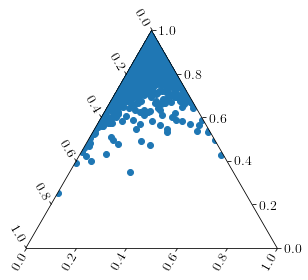

In [30]:
import mpltern

ax = plt.subplot(projection='ternary')
ax.scatter(*posterior_bulge['theta_ics'].T)   

## A. Inspect models

### A.1 NPModel

In [ ]:
from models.np_model import NPModel
from models.poisson_model import PoissonModel
from numpyro.infer.util import Predictive

In [ ]:
npmodel = NPModel(
    r_outer=25,
    l_max=2,
    vary_disk=True,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
    n_exp=1,
    debug_model=True
)

In [ ]:
with numpyro.handlers.seed(rng_seed=234234):
    npmodel.model(npmodel.data)

In [ ]:
Predictive(npmodel.model, num_samples=1, batch_ndims=0)(jax.random.PRNGKey(42), npmodel.data)

### A.2 PoissonModel

In [ ]:
pmodel = PoissonModel(
    r_outer=25,
    l_max=2,
    vary_disk=True,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
    n_exp=1,
    debug_model=True
)

In [ ]:
with numpyro.handlers.seed(rng_seed=234234):
    pmodel.model(pmodel.data)

In [ ]:
Predictive(pmodel.model, num_samples=1, batch_ndims=0)(jax.random.PRNGKey(42), pmodel.data)